# Processed food — Bayesian ARX(4) with stochastic volatility and model-based outliers

This is the second model of the **Headline inflation suite**.

The economic specification follows **ECB Working Paper 374 (2004)**. For euro-area processed food, the selected model is a **dynamic single equation**, not a multivariate BVAR:

- HICP processed food: lags **1–4**;
- food commodity prices: lag **2**;
- compensation per employee: lags **0–2**;
- standard VAT rate: contemporaneous effect;
- 11 monthly seasonal dummies.

The modern Bayesian machinery is inherited from the Energy suite / ECB WP 3062 implementation:

- normal shrinkage centred on white noise for the autoregressive coefficients;
- stochastic volatility;
- model-based transitory outliers;
- the same Gibbs infrastructure and result/registry contract.

The implementation is an **exact replication of the WP374 lag structure**, while modernising the disturbance process and uncertainty treatment. The target is the only endogenous state. The driver terms enter through the shared engine's exogenous-regressor block, so we do not silently replace the selected single equation by a four-variable BVAR.

## Econometric representation

Let

\[
y_t = \Delta\log I_t^{PF}
\]

with \(I_t^{PF}\) the NSA processed-food HICP index. The target equation is

\[
y_t = c + \sum_{j=1}^{4}\beta_j y_{t-j}
      + \gamma\,\Delta\log COMFD_{t-2}
      + \sum_{j=0}^{2}\delta_j\,\Delta\log WAGE_{t-j}
      + \theta\,\Delta(VAT_t/100)
      + d_t'\eta + \nu_t.
\]

The VAT normalisation is explicit: the native data are stored in percentage points (for example `20.5`). The model state uses the rate as a share (`0.205`). A permanent **+1 percentage point** VAT increase therefore creates a one-off model change of `+0.01`, matching the economic interpretation in WP374.

The residual follows the same univariate SV/outlier decomposition used by the Energy engine:

\[
\nu_t=o_t\sqrt{\lambda_t}\varepsilon_t,\qquad
\log\lambda_t=\log\lambda_{t-1}+\eta_t.
\]

## 1. Imports and configuration

In [1]:
1+1

2

In [2]:
from __future__ import annotations

import os
import sys
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/ and src/.")


env_root = os.environ.get("BVAR_PROJECT_ROOT")
PROJECT_ROOT = Path(env_root).expanduser().resolve() if env_root else find_project_root(Path.cwd())
MODEL_DIR = PROJECT_ROOT / "src" / "model"
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

from headline_bvar_model import (
    BVARSVOPriorConfig,
    SamplerConfig,
    forecast_headline_component,
    headline_component_contract_table,
    headline_component_spec,
    headline_driver_assumption_table,
    headline_forecast_horizon_table,
    headline_panel_audit,
    headline_scenario_impact_table,
    headline_series_construction_table,
    headline_transformation_table,
    load_headline_component_panel,
    native_model_differences,
    prepare_headline_component,
    resolve_headline_component_dataset,
    run_headline_bvar,
    wp374_processed_food_posterior_comparison,
    wp374_processed_food_sparse_benchmark,
)

from headline_bvar_plot import (
    plot_headline_driver_assumptions,
    plot_headline_hicp_forecast_fan,
    plot_headline_model_differences,
    plot_headline_native_levels,
    plot_headline_scenario_impact,
)

from energy_bvar_model import (
    coefficient_posterior_table,
    mcmc_diagnostics,
    posterior_predictive_statistics,
    residual_diagnostic_table,
    stability_diagnostics,
    stationarity_tests,
)

from energy_bvar_plot import (
    plot_chain_acf_grid,
    plot_coefficient_heatmap,
    plot_minnesota_prior_by_equation,
    plot_outlier_probabilities,
    plot_phi_and_outlier_priors,
    plot_posterior_predictive_check,
    plot_posterior_volatility,
    plot_shrinkage_comparison,
    plot_spectral_radius,
    plot_standardized_residuals,
    plot_trace_grid,
    style_numeric_table,
)

try:
    from energy_bvar_io import save_energy_bvar_result
except ImportError:
    save_energy_bvar_result = None

COMPONENT = "processed_food"
SPEC = headline_component_spec(COMPONENT)

# None -> data/processed. During development this can point to a scratch build.
DATA_ROOT = None
VINTAGE = None

QUICK_TEST = False
FORECAST_HORIZON = 18
FORECAST_DRAWS = 250 if QUICK_TEST else 1_000
SAVE_RESULTS = False

PRIOR_CONFIG = BVARSVOPriorConfig()  # same project defaults as Energy
SAMPLER_CONFIG = SamplerConfig(
    reps=300 if QUICK_TEST else 6_000,
    burn=150 if QUICK_TEST else 3_000,
    thin=1,
    seed=42,
    progress_every=0 if QUICK_TEST else 500,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("COMPONENT:", COMPONENT)
print("Implementation:", SPEC["implementation_mode"])

PROJECT_ROOT: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy
COMPONENT: processed_food
Implementation: bayesian_arx4_sv_outlier_exact_wp374_lag_structure


## 2. Paper contract and transformation contract

In [3]:
display(headline_component_contract_table())
display(headline_transformation_table(COMPONENT))

,label,dataset_file,target,paper_model_class,paper_lag_structure,active_lags,implementation_mode,production_ready,production_blocker
component,,,,,,,,,
unprocessed_food,Unprocessed food,unprocessed_food_monthly.csv,hicp_unprocessed_food,dynamic single equation / autoregression,"HICP unprocessed food L1, L10, L12 + 11 monthl...",None,dense_bayesian_ar12_shrinkage_approximation,True,None
processed_food,Processed food,processed_food_monthly.csv,hicp_processed_food,dynamic single equation,HICP PF L1-L4; food commodities L2; wages L0-L...,"[1, 2, 3, 4]",bayesian_arx4_sv_outlier_exact_wp374_lag_struc...,True,None
neig,Non-energy industrial goods,neig_monthly.csv,hicp_neig,dynamic single equation,"HICP NEIG L1,L6,L12; PPI consumer goods L1; wa...","[1, 6, 12]",bayesian_sparse_arx12_sv_outlier_exact_wp374_l...,True,None
services,Services,services_monthly.csv,hicp_services,BVAR,Services/wages/PPI consumer goods/unprocessed ...,"[1, 2, 3, 4, 5, 12]",bayesian_sparse_bvar12_sv_outlier_exact_wp374_...,True,None


,role,native_unit,transform,state_level,model_change,state_variable,paper_active_lags
native_series,,,,,,,
hicp_processed_food,target,HICP index,logdiff,log(hicp_processed_food),Δlog(hicp_processed_food),state__hicp_processed_food,"[1, 2, 3, 4]"
food_commodity_price,driver,index,logdiff,log(food_commodity_price),Δlog(food_commodity_price),state__food_commodity_price,[2]
compensation_per_employee,driver,compensation per employee,logdiff,log(compensation_per_employee),Δlog(compensation_per_employee),state__compensation_per_employee,"[0, 1, 2]"
vat_standard_ea,driver,% standard VAT rate,percent_rate_diff,vat_standard_ea/100,Δ(vat_standard_ea/100),state__vat_standard_ea,[0]


The key architectural point is that **the transformations are explicit and reversible**:

- `hicp_processed_food`, `food_commodity_price`, `compensation_per_employee`: native positive level → log state → first difference;
- `vat_standard_ea`: percentage-point rate → rate share (`/100`) → first difference.

Only `hicp_processed_food` is endogenous. The exact WP374 driver terms are generated as deterministic/exogenous regressors.

## 3. Load native processed-food panel

In [4]:
DATASET_PATH = resolve_headline_component_dataset(
    PROJECT_ROOT,
    COMPONENT,
    vintage=VINTAGE,
    data_root=DATA_ROOT,
)
VINTAGE_USED = DATASET_PATH.parent.name
native_levels = load_headline_component_panel(DATASET_PATH, COMPONENT)

print("Dataset:", DATASET_PATH)
print("Vintage:", VINTAGE_USED)
display(headline_series_construction_table(DATASET_PATH, COMPONENT))
display(headline_panel_audit(native_levels, COMPONENT))

Dataset: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260811\processed_food_monthly.csv
Vintage: 20260811


,dataset_file,role,native_unit,transform,state_level,model_change,state_variable,paper_active_lags,paper_model_class,paper_lag_structure,implementation_mode
native_series,,,,,,,,,,,
hicp_processed_food,processed_food_monthly.csv,target,HICP index,logdiff,log(hicp_processed_food),Δlog(hicp_processed_food),state__hicp_processed_food,"[1, 2, 3, 4]",dynamic single equation,HICP PF L1-L4; food commodities L2; wages L0-L...,bayesian_arx4_sv_outlier_exact_wp374_lag_struc...
food_commodity_price,processed_food_monthly.csv,driver,index,logdiff,log(food_commodity_price),Δlog(food_commodity_price),state__food_commodity_price,[2],dynamic single equation,HICP PF L1-L4; food commodities L2; wages L0-L...,bayesian_arx4_sv_outlier_exact_wp374_lag_struc...
compensation_per_employee,processed_food_monthly.csv,driver,compensation per employee,logdiff,log(compensation_per_employee),Δlog(compensation_per_employee),state__compensation_per_employee,"[0, 1, 2]",dynamic single equation,HICP PF L1-L4; food commodities L2; wages L0-L...,bayesian_arx4_sv_outlier_exact_wp374_lag_struc...
vat_standard_ea,processed_food_monthly.csv,driver,% standard VAT rate,percent_rate_diff,vat_standard_ea/100,Δ(vat_standard_ea/100),state__vat_standard_ea,[0],dynamic single equation,HICP PF L1-L4; food commodities L2; wages L0-L...,bayesian_arx4_sv_outlier_exact_wp374_lag_struc...


,role,unit,first_observed,last_observed,n_calendar,n_observed,n_missing,missing_share
series,,,,,,,,
hicp_processed_food,target,HICP index,1996-01-01,2026-07-01,367,367,0,0.000000
food_commodity_price,exogenous_driver,index,2006-01-01,2026-07-01,367,247,120,0.326975
compensation_per_employee,exogenous_driver,compensation per employee,2000-03-01,2026-03-01,367,313,54,0.147139
vat_standard_ea,exogenous_driver,% standard VAT rate,1996-01-01,2026-07-01,367,367,0,0.000000


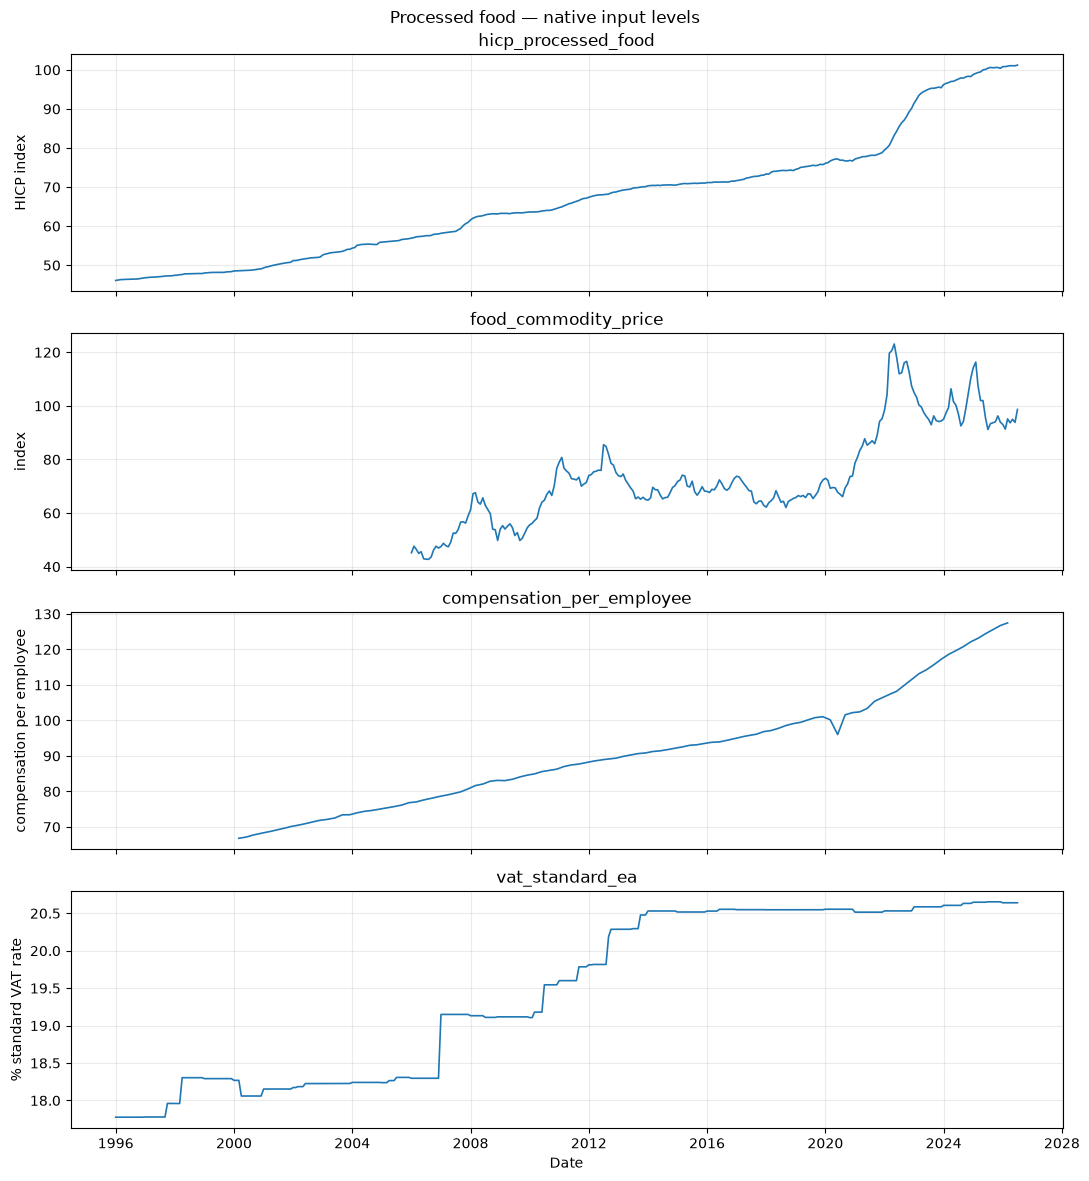

In [5]:
plot_headline_native_levels(
    native_levels,
    component_label=SPEC["label"],
    units=SPEC["units"],
)
plt.show()

## 4. Model-space transformations

,count,mean,std,min,25%,50%,75%,max
hicp_processed_food,366.0,0.002149,0.002822,-0.004284,0.000568,0.001430,0.002796,0.015855
food_commodity_price,246.0,0.003174,0.033138,-0.101352,-0.017751,0.003541,0.021932,0.138355
compensation_per_employee,312.0,0.002071,0.002584,-0.014491,0.001359,0.001862,0.002727,0.018934
vat_standard_ea,366.0,0.000078,0.000593,-0.002091,0.000000,0.000000,0.000000,0.008526


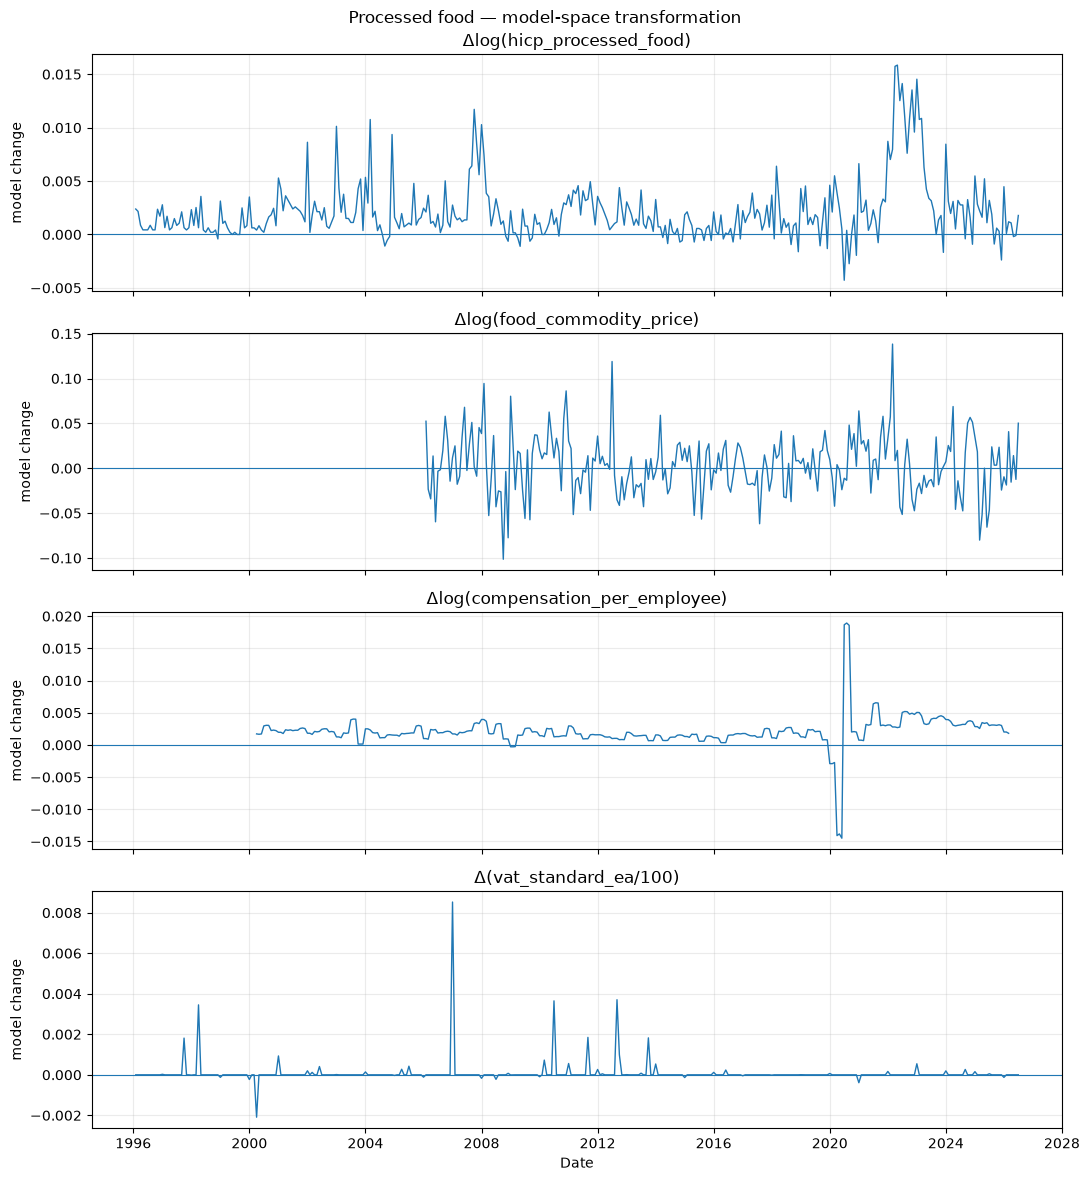

In [6]:
model_differences = native_model_differences(native_levels, COMPONENT)
transform_labels = headline_transformation_table(COMPONENT)["model_change"].to_dict()

display(model_differences.describe().T)
plot_headline_model_differences(
    model_differences,
    component_label=SPEC["label"],
    transform_labels=transform_labels,
)
plt.show()

### Ragged-edge policy for exogenous drivers

The exact WP374 processed-food equation treats food commodities, wages and VAT as **exogenous regressors**. Consequently, the DK smoother cannot draw a missing wage observation as if wages were another endogenous VAR variable without changing the model class.

The adapter therefore follows an explicit conditional-forecast convention at the **trailing edge only**:

- no interior gap is ever filled;
- after the last available driver observation, its native level is held constant;
- this is equivalent to zero future transformed change;
- every affected month is recorded below.

This is a conditioning assumption, not an observed-data claim. A later release of the driver automatically replaces the assumption in the next vintage.

## 5. Build the exact sparse ARX design

In [7]:
prepared = prepare_headline_component(native_levels, COMPONENT)

print("Endogenous state columns:", list(prepared["state_levels"].columns))
print("Exogenous design columns:")
for name in prepared["exog"].columns:
    print("  ", name)
print("First regression date:", prepared["first_regression_date"])
print("Model calendar starts:", prepared["model_start"])

display(prepared["predictor_edge_audit"])

Endogenous state columns: ['state__hicp_processed_food']
Exogenous design columns:
   food_commodity_price_L2
   compensation_per_employee_L0
   compensation_per_employee_L1
   compensation_per_employee_L2
   vat_standard_ea_L0
   month_01
   month_02
   month_03
   month_04
   month_05
   month_06
   month_07
   month_08
   month_09
   month_10
   month_11
First regression date: 2006-04-01 00:00:00
Model calendar starts: 2005-12-01 00:00:00


,first_observed,last_observed,trailing_months_conditioned,edge_policy
driver,,,,
food_commodity_price,2006-01-01,2026-07-01,0,flat_native_level
compensation_per_employee,2000-03-01,2026-03-01,4,flat_native_level
vat_standard_ea,1996-01-01,2026-07-01,0,flat_native_level


The design must contain exactly:

```text
food_commodity_price_L2
compensation_per_employee_L0
compensation_per_employee_L1
compensation_per_employee_L2
vat_standard_ea_L0
month_01 ... month_11
```

The AR(1–4) terms are generated by the shared engine from the endogenous processed-food state itself.

## 6. Exact WP374 OLS benchmark

In [8]:
wp374 = wp374_processed_food_sparse_benchmark(native_levels)

display(wp374["comparison"])
display(wp374["fit"].summary2().tables[1])

print("Current benchmark sample:", wp374["data"].index.min(), "→", wp374["data"].index.max())
print("R²:", round(float(wp374["fit"].rsquared), 4))
print("VAT normalization:", wp374["vat_normalisation"])

,WP374_reported,current_sample
HICP_L1,0.2654,0.550653
HICP_L2,0.0165,0.289808
HICP_L3,0.2690,0.121640
HICP_L4,0.0078,-0.104358
COMFD_L2,0.0055,0.008340
WAGES_L0,0.1827,-0.107096
WAGES_L1,-0.2024,0.178390
WAGES_L2,0.1710,-0.027764
VAT_L0,0.0453,-0.200261


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,-0.001591,0.000421,-3.779914,2.022994e-04,-0.002420,-0.000761
HICP_L1,0.550653,0.066862,8.235678,1.612646e-14,0.418878,0.682428
HICP_L2,0.289808,0.075534,3.836766,1.630812e-04,0.140940,0.438675
HICP_L3,0.121640,0.075575,1.609537,1.089395e-01,-0.027306,0.270587
HICP_L4,-0.104358,0.066846,-1.561177,1.199258e-01,-0.236102,0.027385
COMFD_L2,0.008340,0.003564,2.340039,2.018136e-02,0.001316,0.015363
WAGES_L0,-0.107096,0.051294,-2.087875,3.796532e-02,-0.208189,-0.006002
WAGES_L1,0.178390,0.061551,2.898229,4.134204e-03,0.057081,0.299699
WAGES_L2,-0.027764,0.050828,-0.546233,5.854619e-01,-0.127939,0.072411
VAT_L0,-0.200261,0.170186,-1.176718,2.405854e-01,-0.535672,0.135151


Current benchmark sample: 2006-04-01 00:00:00 → 2026-03-01 00:00:00
R²: 0.744
VAT normalization: native percentage points / 100 before first difference


WP374 reports approximately:

- target `L1=0.2654`, `L2=0.0165`, `L3=0.2690`, `L4=0.0078`;
- food commodities `L2=0.0055`;
- wages `L0=0.1827`, `L1=-0.2024`, `L2=0.1710`;
- VAT `L0=0.0453`.

Our current sample cannot be expected to reproduce those numerical coefficients because the modern food-commodity proxy starts much later than the 1990–2002 sample in WP374. The useful benchmark is the **specification and sign/magnitude plausibility**, not numerical equality.

## 7. Bayesian priors

In [9]:
display(pd.Series(asdict(PRIOR_CONFIG), name="value").to_frame())
display(pd.Series(asdict(SAMPLER_CONFIG), name="value").to_frame())

,value
lambda1,2.000000e-01
lambda2,5.000000e-01
lambda3,1.000000e+00
lambda4,1.000000e+01
a_prior_var,1.000000e+01
phi_prior_mean,2.000000e-02
phi_prior_df,1.000000e+01
h0_var,4.000000e+00
outlier_mean_frequency,2.083333e-02
outlier_prior_observations,1.200000e+02


,value
reps,6000
burn,3000
thin,1
seed,42
max_stability_tries,1000
progress_every,500
sv_sampler,centered_ksc
dk_projection_mode,strict
dk_level_relative_gate,0.000001
dk_difference_relative_gate,0.000001


The AR(1–4) coefficients receive the same Minnesota-style normal shrinkage used by the Energy suite. The external driver coefficients and seasonal dummies use the shared engine's diffuse exogenous prior scale. Stochastic-volatility and outlier priors are unchanged from the validated Energy implementation.

## 8. Gibbs estimation

In [10]:
result = run_headline_bvar(
    prepared,
    component=COMPONENT,
    vintage=VINTAGE_USED,
    prior_config=PRIOR_CONFIG,
    sampler_config=SAMPLER_CONFIG,
    exog_prior_scale=10.0,
    code_version="headline-processed-food-v1",
)

print("Run ID:", result["metadata"]["run_id"])
print("Posterior draws:", result["n_draws"])
print("Endogenous variables:", result["variables"])
print("AR order:", result["p"])
print("Exogenous regressors:", result["prep"]["exog_names"])
print("Balanced end:", result["prep"]["balanced_end"])

iteration 500/6,000 | B instability rejection 0.00% | radius 0.8273
iteration 1,000/6,000 | B instability rejection 0.00% | radius 0.8812
iteration 1,500/6,000 | B instability rejection 0.00% | radius 0.8902
iteration 2,000/6,000 | B instability rejection 0.00% | radius 0.8584
iteration 2,500/6,000 | B instability rejection 0.00% | radius 0.7819
iteration 3,000/6,000 | B instability rejection 0.00% | radius 0.8416
iteration 3,500/6,000 | B instability rejection 0.00% | radius 0.8719
iteration 4,000/6,000 | B instability rejection 0.00% | radius 0.8704
iteration 4,500/6,000 | B instability rejection 0.00% | radius 0.8076
iteration 5,000/6,000 | B instability rejection 0.00% | radius 0.8478
iteration 5,500/6,000 | B instability rejection 0.00% | radius 0.8758
iteration 6,000/6,000 | B instability rejection 0.00% | radius 0.7968
Run ID: 8a59431be79e36fc6ae6e0a4b3401692d66c0de679c68bc8bfd3ffa688543622
Posterior draws: 3000
Endogenous variables: ['state__hicp_processed_food']
AR order: 4
Ex

## 9. Prior and posterior coefficients

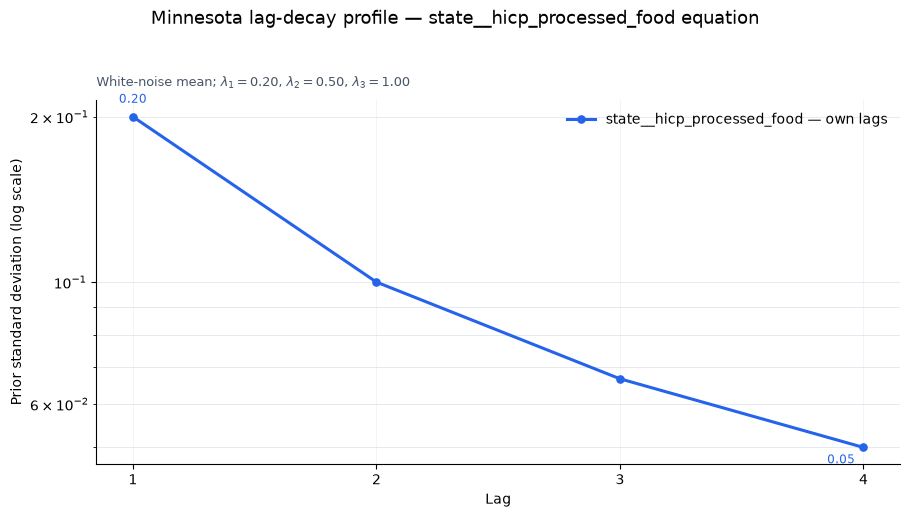

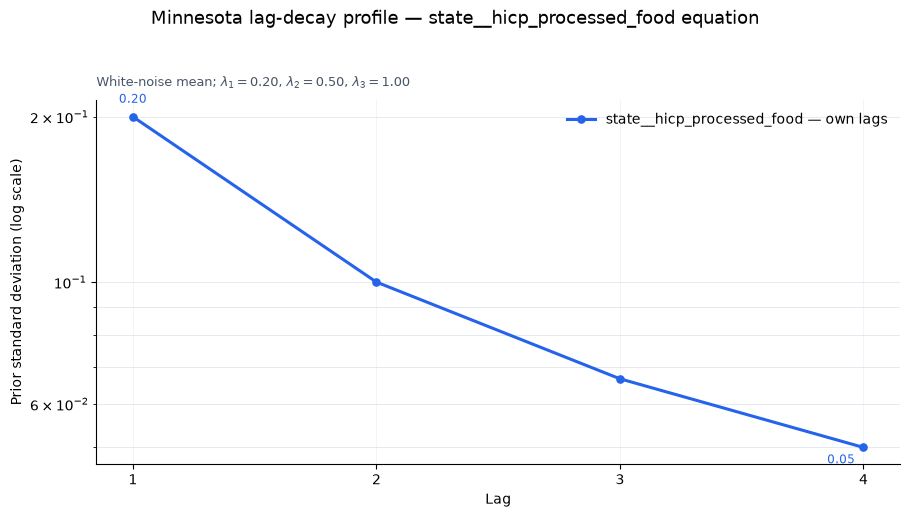

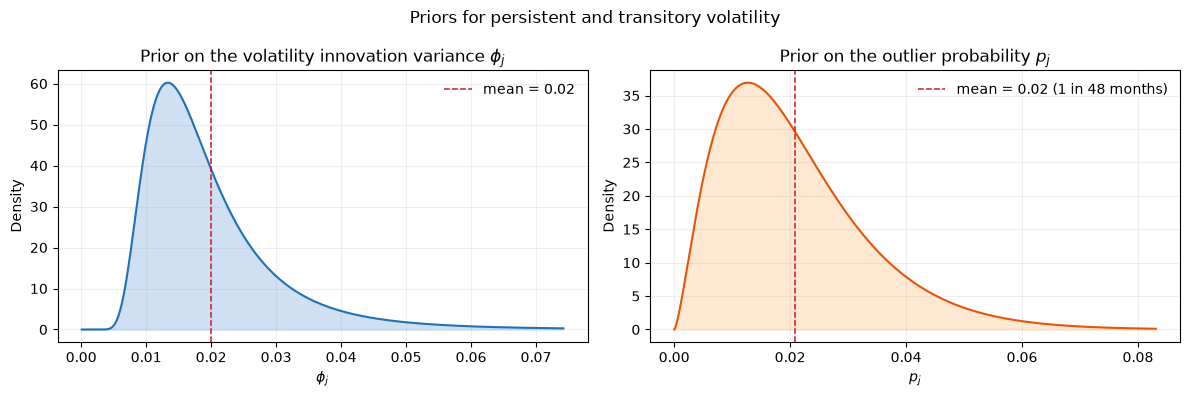

In [11]:
prior_figures = plot_minnesota_prior_by_equation(
    result["prior"], result["variables"], result["p"]
)
display(prior_figures[result["variables"][0]])

plot_phi_and_outlier_priors(result["prior"])
plt.show()

,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
state__hicp_processed_food: const,0.00,0.02,-1.26 × 10⁻³,-1.25 × 10⁻³,3.31 × 10⁻⁴,-1.81 × 10⁻³,-1.59 × 10⁻³,-9.37 × 10⁻⁴,-7.24 × 10⁻⁴,1895.24
state__hicp_processed_food: state__hicp_processed_food L1,0.00,0.20,0.46,0.46,0.06,0.35,0.40,0.53,0.57,706.48
state__hicp_processed_food: state__hicp_processed_food L2,0.00,0.10,0.25,0.25,0.05,0.16,0.19,0.30,0.34,1963.98
state__hicp_processed_food: state__hicp_processed_food L3,0.00,0.07,0.06,0.06,0.05,-0.02,0.01,0.11,0.14,2002.10
state__hicp_processed_food: state__hicp_processed_food L4,0.00,0.05,0.01,0.01,0.04,-0.05,-0.03,0.05,0.07,1905.64
state__hicp_processed_food: food_commodity_price_L2,0.00,0.02,4.84 × 10⁻³,4.69 × 10⁻³,3.10 × 10⁻³,-8.30 × 10⁻⁵,1.72 × 10⁻³,7.97 × 10⁻³,0.01,920.97
state__hicp_processed_food: compensation_per_employee_L0,0.00,0.02,-4.82 × 10⁻³,-5.19 × 10⁻³,0.02,-0.04,-0.03,0.02,0.03,2345.94
state__hicp_processed_food: compensation_per_employee_L1,0.00,0.02,0.02,0.02,0.02,-0.02,-5.29 × 10⁻³,0.04,0.05,2388.76
state__hicp_processed_food: compensation_per_employee_L2,0.00,0.02,9.42 × 10⁻³,9.70 × 10⁻³,0.02,-0.03,-0.01,0.03,0.04,2388.28
state__hicp_processed_food: vat_standard_ea_L0,0.00,0.02,-5.52 × 10⁻⁴,-4.98 × 10⁻⁴,0.02,-0.04,-0.02,0.02,0.04,2925.97


,WP374_reported,posterior_median,q16,q84,posterior_sd,ESS
term,,,,,,
HICP_L1,0.27,0.46,0.40,0.53,0.06,706.48
HICP_L2,0.02,0.25,0.19,0.30,0.05,1963.98
HICP_L3,0.27,0.06,0.01,0.11,0.05,2002.10
HICP_L4,7.80 × 10⁻³,0.01,-0.03,0.05,0.04,1905.64
COMFD_L2,5.50 × 10⁻³,4.69 × 10⁻³,1.72 × 10⁻³,7.97 × 10⁻³,3.10 × 10⁻³,920.97
WAGES_L0,0.18,-5.19 × 10⁻³,-0.03,0.02,0.02,2345.94
WAGES_L1,-0.20,0.02,-5.29 × 10⁻³,0.04,0.02,2388.76
WAGES_L2,0.17,9.70 × 10⁻³,-0.01,0.03,0.02,2388.28
VAT_L0,0.05,-4.98 × 10⁻⁴,-0.02,0.02,0.02,2925.97


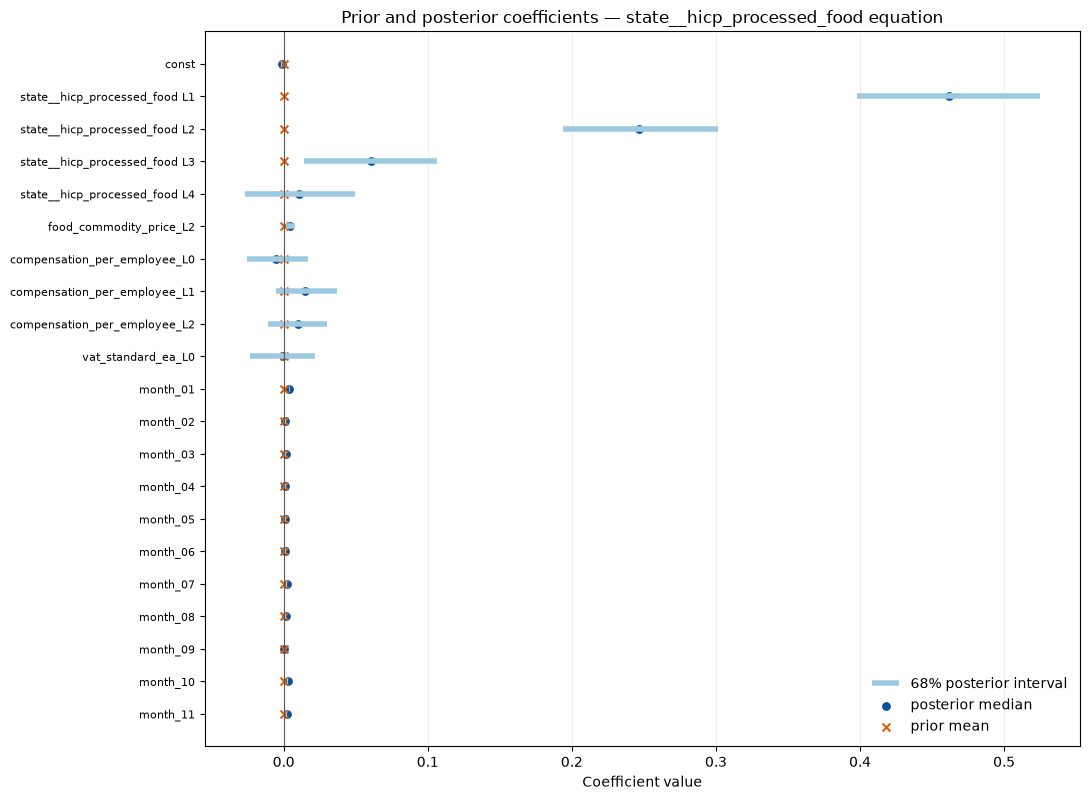

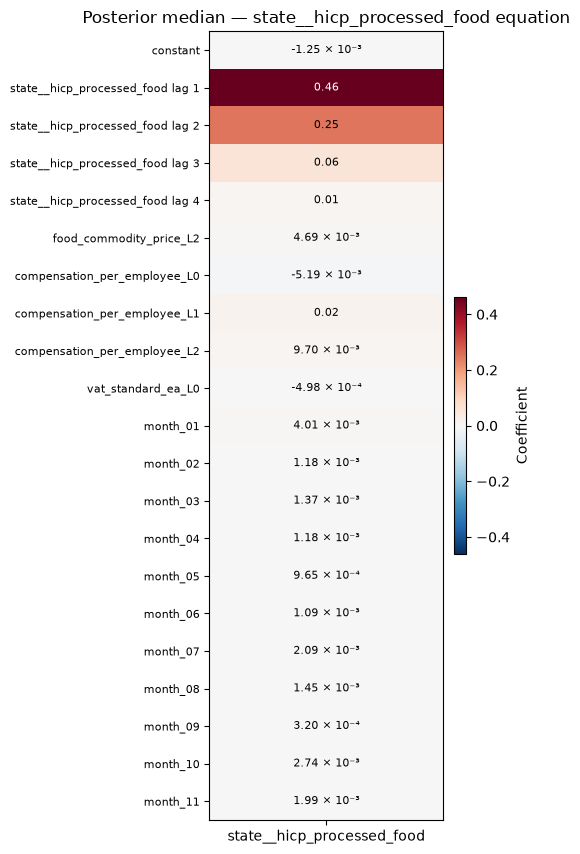

In [12]:
coef = coefficient_posterior_table(result)
display(style_numeric_table(coef, caption="Processed-food posterior coefficients"))

display(
    style_numeric_table(
        wp374_processed_food_posterior_comparison(result),
        caption="WP374 reported coefficients vs modern Bayesian posterior",
    )
)

plot_shrinkage_comparison(result)
plt.show()

plot_coefficient_heatmap(result, equation=result["variables"][0])
plt.show()

## 10. Stochastic volatility, outliers and residuals

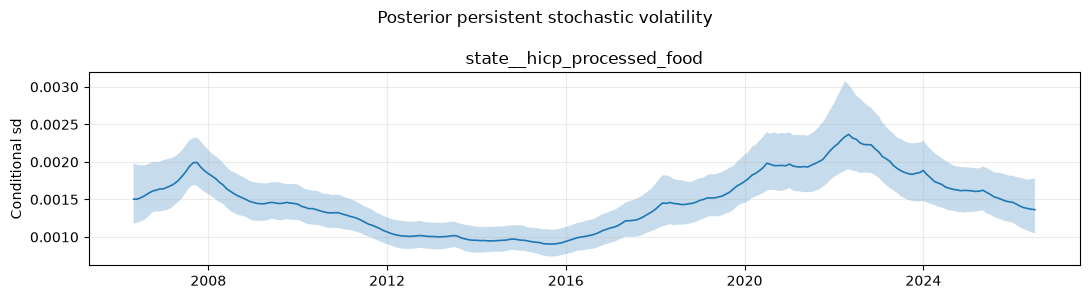

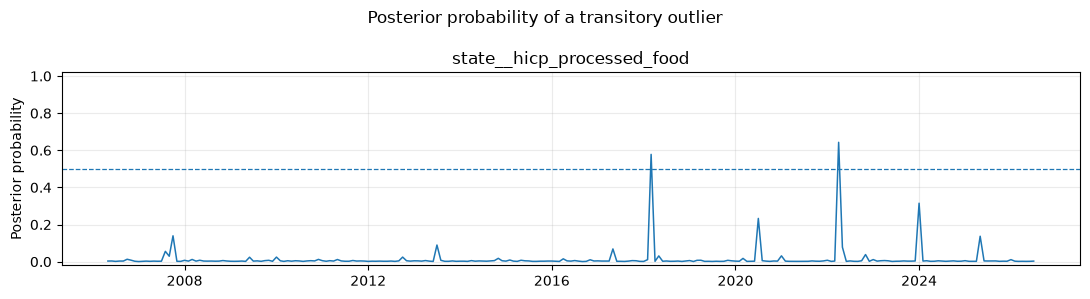

,mean,sd,skewness,excess_kurtosis,acf_1,maximum_absolute
variable,,,,,,
state__hicp_processed_food,0.05,0.96,0.54,0.53,-0.05,3.12


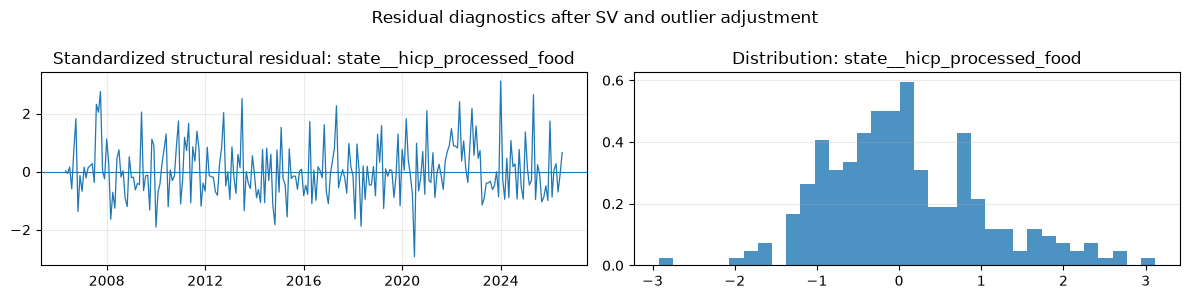

In [13]:
plot_posterior_volatility(result, include_outliers=False)
plt.show()

plot_outlier_probabilities(result)
plt.show()

residual_diag = residual_diagnostic_table(result)
display(style_numeric_table(residual_diag, caption="Residual diagnostics"))
plot_standardized_residuals(result)
plt.show()

## 11. Baseline conditional forecast

Unlike the unprocessed-food AR, the processed-food equation contains external regressors. A forecast therefore always embeds assumptions about their future paths.

The default **baseline conditional forecast** holds the native levels of food commodities, compensation per employee and VAT constant from their latest available/conditioned levels. This produces zero new transformed changes after the forecast origin, while the first forecast months still inherit the appropriate historical lagged changes.

This is intentionally not labelled an unconditional forecast. `native_driver_paths` can later be supplied directly by the dashboard or a scenario engine.

In [14]:
baseline = forecast_headline_component(
    result,
    component=COMPONENT,
    H=FORECAST_HORIZON,
    native_levels=native_levels,
    n_draws=min(FORECAST_DRAWS, result["n_draws"]),
    simulate_future_outliers=True,
    seed=2026,
)

print("Forecast contract:", baseline["forecast_contract_version"])
print("Driver policy:", baseline["driver_forecast_policy"])
display(headline_driver_assumption_table(result))

Forecast contract: headline-hicp-component-v1
Driver policy: flat_native_level


,first_observed,last_observed,trailing_months_conditioned,edge_policy
driver,,,,
food_commodity_price,2006-01-01,2026-07-01,0,flat_native_level
compensation_per_employee,2000-03-01,2026-03-01,4,flat_native_level
vat_standard_ea,1996-01-01,2026-07-01,0,flat_native_level


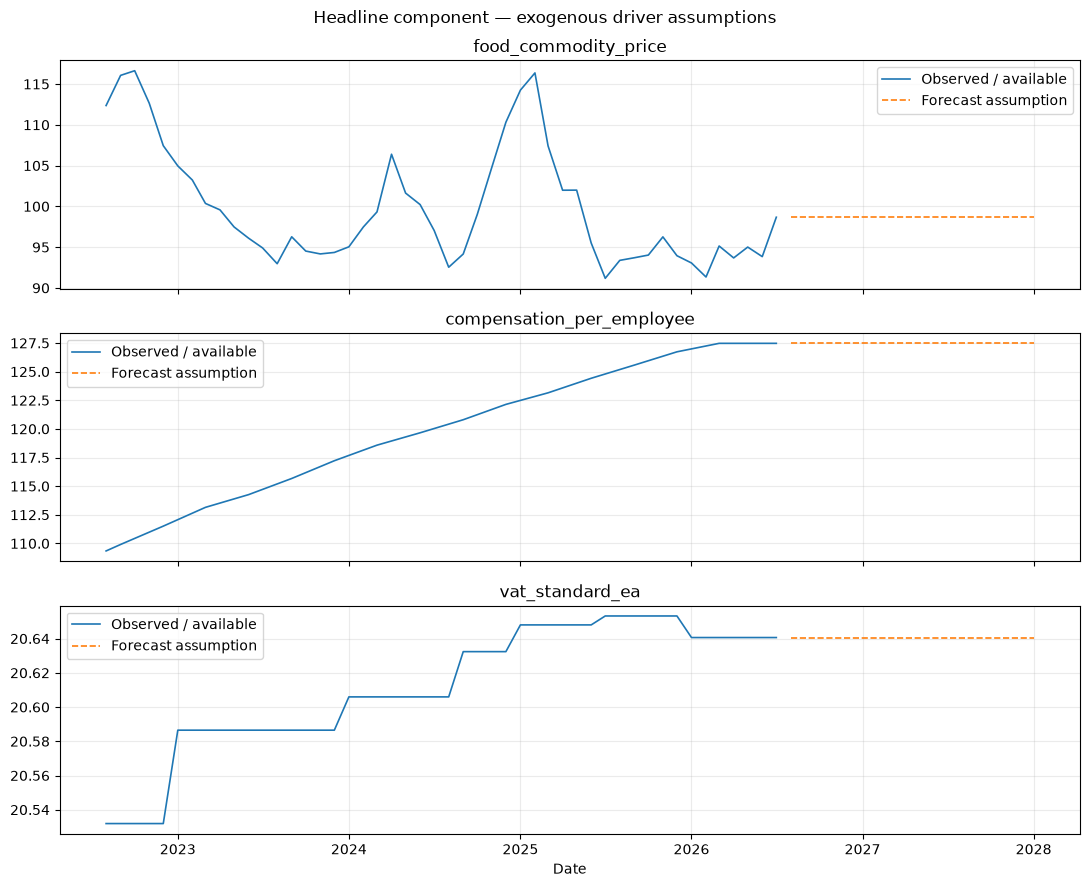

In [15]:
plot_headline_driver_assumptions(
    prepared["design_native_levels"],
    baseline,
    last_obs=48,
)
plt.show()

In [16]:
print("HICP processed-food index")
display(headline_forecast_horizon_table(baseline, kind="level"))

print("HICP processed-food YoY inflation")
display(headline_forecast_horizon_table(baseline, kind="yoy"))

HICP processed-food index


,target_date,q05,q16,median,q84,q95
months_ahead,,,,,,
1,2026-08-01,101.048282,101.160372,101.313461,101.460700,101.579678
3,2026-10-01,100.765330,101.116013,101.508699,101.930364,102.259747
6,2027-01-01,100.383769,101.139923,101.991215,102.892382,103.740644
12,2027-07-01,99.007458,100.903182,102.748896,104.522543,106.701623
18,2028-01-01,97.574407,100.767916,103.596372,106.335381,109.494106


HICP processed-food YoY inflation


,target_date,q05,q16,median,q84,q95
months_ahead,,,,,,
1,2026-08-01,0.425643,0.537042,0.689188,0.835519,0.953765
3,2026-10-01,0.174301,0.522928,0.913310,1.332502,1.659953
6,2027-01-01,-0.442558,0.307372,1.151656,2.045405,2.886684
12,2027-07-01,-2.185874,-0.312999,1.510469,3.262738,5.415553
18,2028-01-01,-3.505926,-0.689635,1.549397,3.549365,5.792677


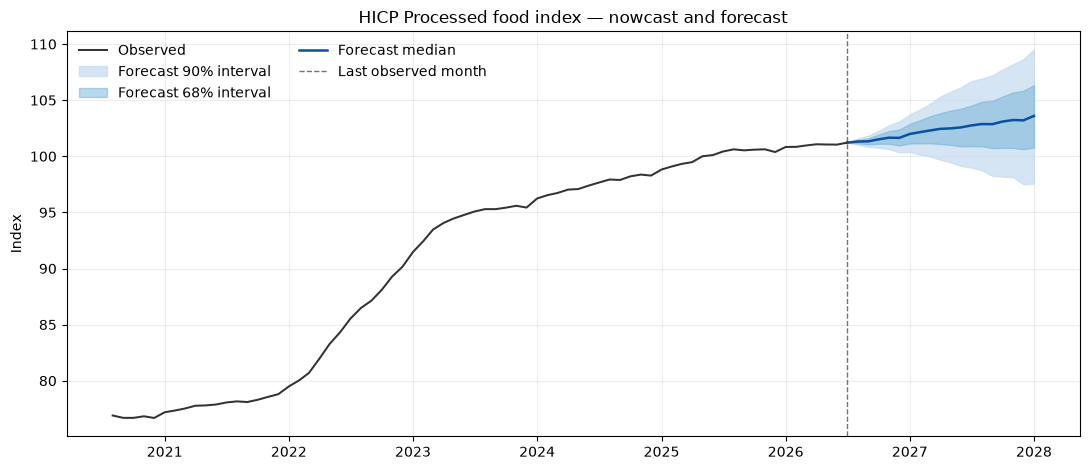

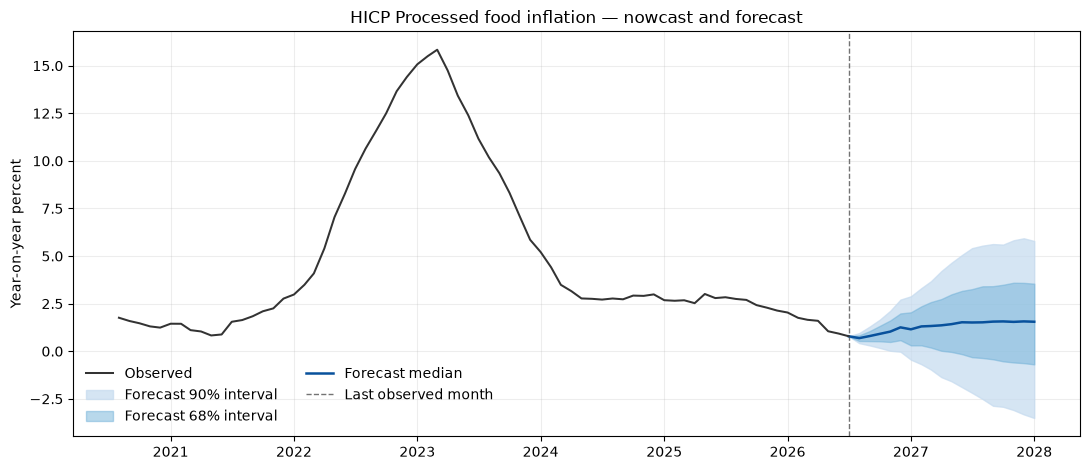

In [17]:
plot_headline_hicp_forecast_fan(baseline, kind="level", last_obs=72)
plt.show()

plot_headline_hicp_forecast_fan(baseline, kind="yoy", last_obs=72)
plt.show()

## 12. Conditional sensitivities — dashboard-ready

WP374 reports the effect of a 1% change in wages/food commodities and a 1 percentage-point VAT change by comparing forecast paths. We retain the same spirit and use the same draw indices/seed for baseline and scenario forecasts.

These are **conditional sensitivities**, not structurally identified shocks.

In [18]:
H = FORECAST_HORIZON
last_used = prepared["design_native_levels"].ffill().iloc[-1]

commodity_scenario = forecast_headline_component(
    result,
    component=COMPONENT,
    H=H,
    native_levels=native_levels,
    n_draws=min(FORECAST_DRAWS, result["n_draws"]),
    simulate_future_outliers=False,
    seed=777,
    native_driver_paths={
        "food_commodity_price": float(last_used["food_commodity_price"]) * 1.10,
    },
)
commodity_baseline = forecast_headline_component(
    result,
    component=COMPONENT,
    H=H,
    native_levels=native_levels,
    n_draws=min(FORECAST_DRAWS, result["n_draws"]),
    simulate_future_outliers=False,
    seed=777,
)

wage_scenario = forecast_headline_component(
    result,
    component=COMPONENT,
    H=H,
    native_levels=native_levels,
    n_draws=min(FORECAST_DRAWS, result["n_draws"]),
    simulate_future_outliers=False,
    seed=778,
    native_driver_paths={
        "compensation_per_employee": float(last_used["compensation_per_employee"]) * 1.01,
    },
)
wage_baseline = forecast_headline_component(
    result,
    component=COMPONENT,
    H=H,
    native_levels=native_levels,
    n_draws=min(FORECAST_DRAWS, result["n_draws"]),
    simulate_future_outliers=False,
    seed=778,
)

vat_scenario = forecast_headline_component(
    result,
    component=COMPONENT,
    H=H,
    native_levels=native_levels,
    n_draws=min(FORECAST_DRAWS, result["n_draws"]),
    simulate_future_outliers=False,
    seed=779,
    native_driver_paths={
        "vat_standard_ea": float(last_used["vat_standard_ea"]) + 1.0,
    },
)
vat_baseline = forecast_headline_component(
    result,
    component=COMPONENT,
    H=H,
    native_levels=native_levels,
    n_draws=min(FORECAST_DRAWS, result["n_draws"]),
    simulate_future_outliers=False,
    seed=779,
)

Permanent +10% food-commodity level shock


,target_date,q05,q16,median,q84,q95
months_ahead,,,,,,
1,2026-08-01,0.000000,0.000000,0.000000,0.000000,0.000000
2,2026-09-01,0.000000,0.000000,0.000000,0.000000,0.000000
3,2026-10-01,-0.001894,0.016575,0.044945,0.076913,0.097173
6,2027-01-01,-0.003791,0.036987,0.105376,0.180544,0.228364
12,2027-07-01,-0.005247,0.058575,0.167719,0.297549,0.384482
18,2028-01-01,-0.002706,0.027420,0.081338,0.167361,0.236537


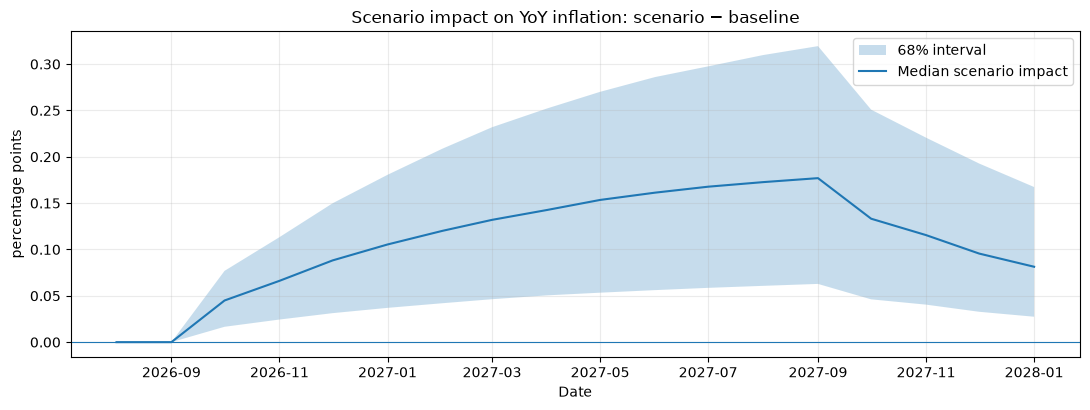

Permanent +1% compensation-per-employee level shock


,target_date,q05,q16,median,q84,q95
months_ahead,,,,,,
1,2026-08-01,-0.036717,-0.024235,-0.002900,0.016430,0.031367
2,2026-09-01,-0.043066,-0.023967,0.008999,0.043541,0.064165
3,2026-10-01,-0.056838,-0.023936,0.022375,0.072953,0.104796
6,2027-01-01,-0.089720,-0.036506,0.049078,0.135416,0.193306
12,2027-07-01,-0.126775,-0.050044,0.074636,0.201027,0.276556
18,2028-01-01,-0.057003,-0.018872,0.033708,0.090571,0.136317


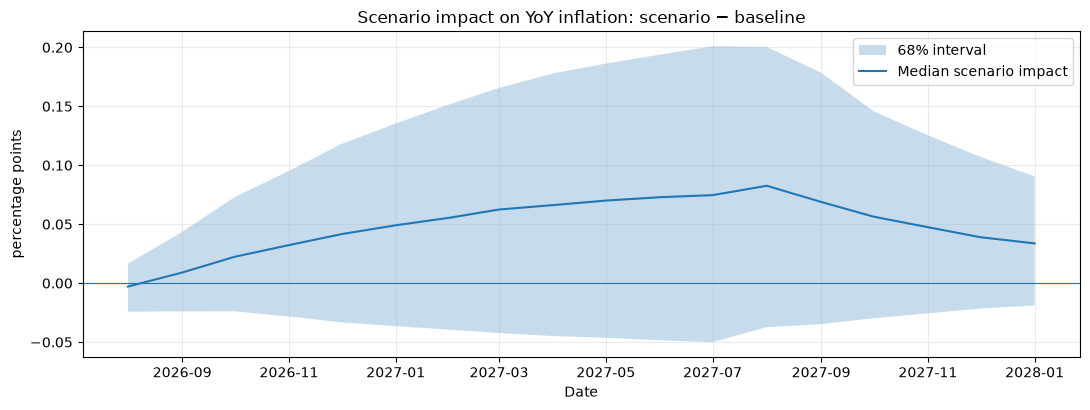

Permanent +1 percentage-point VAT-rate shock


,target_date,q05,q16,median,q84,q95
months_ahead,,,,,,
1,2026-08-01,-0.038508,-0.023458,-0.000266,0.021904,0.037368
2,2026-09-01,-0.056451,-0.034273,-0.000409,0.031912,0.054786
3,2026-10-01,-0.074062,-0.045089,-0.000554,0.042270,0.073270
6,2027-01-01,-0.110693,-0.068693,-0.000919,0.064284,0.111157
12,2027-07-01,-0.149338,-0.093182,-0.001390,0.088212,0.150851
18,2028-01-01,-0.056186,-0.032148,-0.000430,0.031576,0.057743


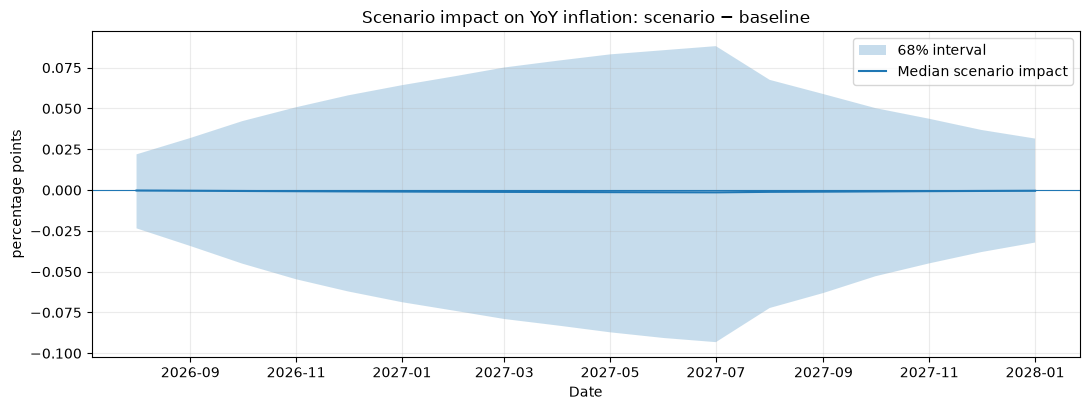

In [19]:
print("Permanent +10% food-commodity level shock")
display(headline_scenario_impact_table(commodity_baseline, commodity_scenario, kind="yoy"))
plot_headline_scenario_impact(commodity_baseline, commodity_scenario, kind="yoy")
plt.show()

print("Permanent +1% compensation-per-employee level shock")
display(headline_scenario_impact_table(wage_baseline, wage_scenario, kind="yoy"))
plot_headline_scenario_impact(wage_baseline, wage_scenario, kind="yoy")
plt.show()

print("Permanent +1 percentage-point VAT-rate shock")
display(headline_scenario_impact_table(vat_baseline, vat_scenario, kind="yoy"))
plot_headline_scenario_impact(vat_baseline, vat_scenario, kind="yoy")
plt.show()

Expected timing from the exact lag structure:

- VAT: impact can start immediately (`L0`);
- wages: impact can start immediately and propagate through `L0–L2` plus target persistence;
- food commodities: direct effect starts only after two months (`L2`).

This is a useful implementation guard for the future dashboard scenario engine.

## 13. MCMC and model diagnostics

,posterior_mean,posterior_sd,ESS,MCSE_mean,MCSE_over_sd
log likelihood,1241.02,6.99,320.01,0.39,0.06
spectral radius,0.85,0.04,966.57,1.33 × 10⁻³,0.03
phi[state__hicp_processed_food],0.02,9.36 × 10⁻³,59.01,1.22 × 10⁻³,0.13
p_outlier[state__hicp_processed_food],0.02,9.17 × 10⁻³,419.83,4.48 × 10⁻⁴,0.05
own L1[state__hicp_processed_food],0.46,0.06,706.48,2.43 × 10⁻³,0.04


,value
retained_draws,3000.000000
median_spectral_radius,0.852755
q95_spectral_radius,0.906531
maximum_spectral_radius,0.974693
retained_unstable_share,0.000000
B_total_proposals,6000.000000
B_unstable_proposals,0.000000
B_instability_rejection_rate,0.000000


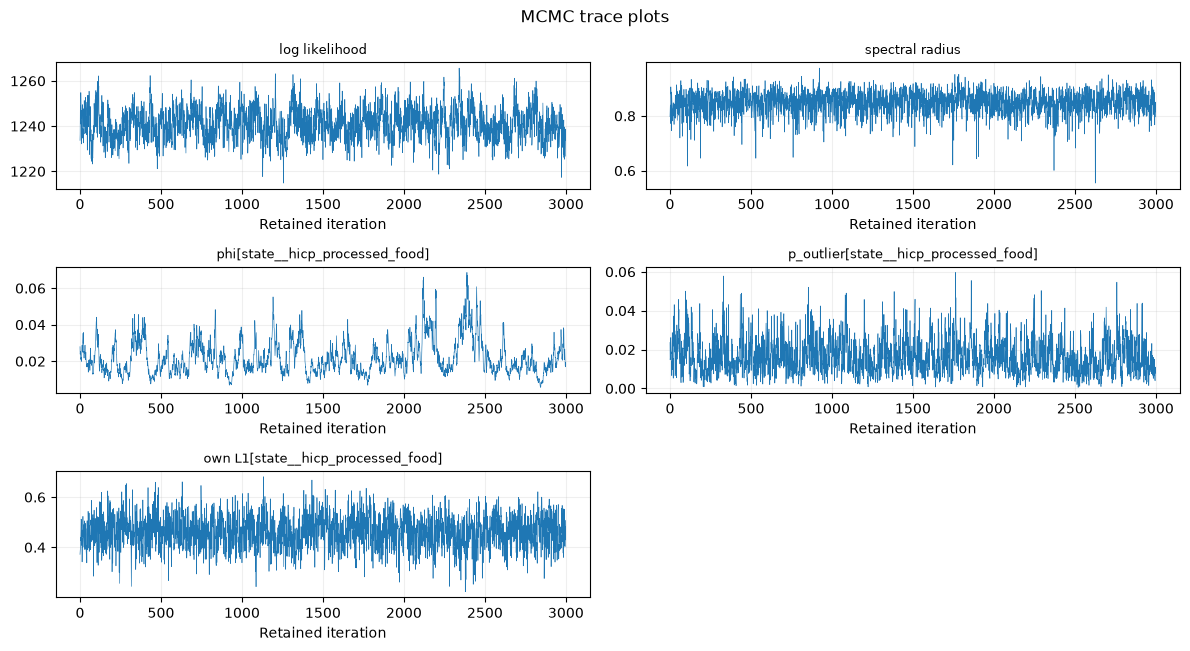

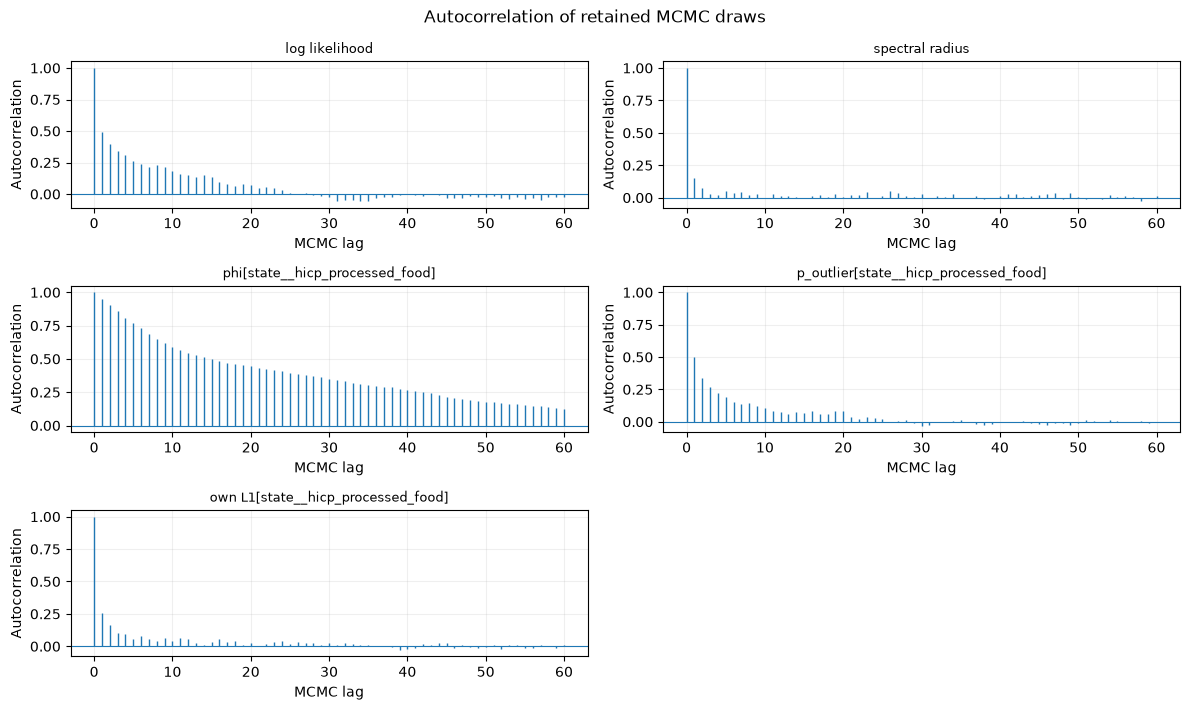

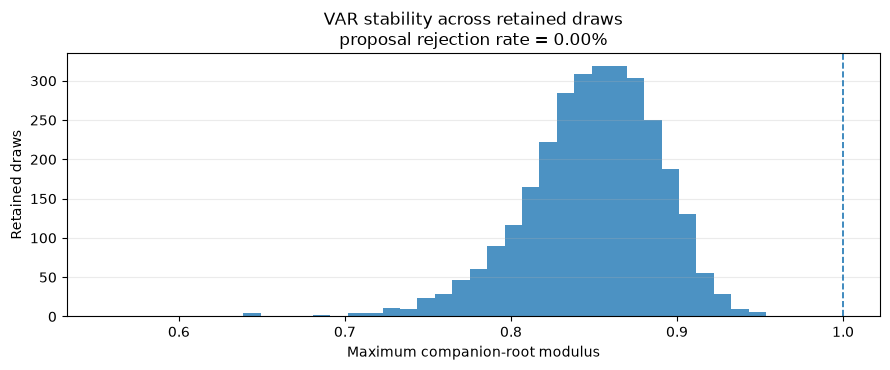

In [20]:
display(style_numeric_table(mcmc_diagnostics(result), caption="MCMC diagnostics"))
display(stability_diagnostics(result).to_frame("value"))

plot_trace_grid(result)
plt.show()

plot_chain_acf_grid(result)
plt.show()

plot_spectral_radius(result)
plt.show()

## 14. Stationarity diagnostics

In [21]:
transformed = native_model_differences(native_levels, COMPONENT)
# Driver-edge assumptions are not inserted here: stationarity tests use actual transformed data only.
display(stationarity_tests(transformed.dropna()))

,ADF statistic,ADF p-value,ADF lags,KPSS statistic,KPSS p-value,KPSS lags,observations
variable,,,,,,,
hicp_processed_food,-3.808711,2.819441e-03,12,0.247338,0.100000,9,229
food_commodity_price,-12.189129,1.297912e-22,0,0.065815,0.100000,5,241
compensation_per_employee,-2.703447,7.344363e-02,12,0.562503,0.027589,4,229
vat_standard_ea,-15.261557,4.852854e-28,0,0.485318,0.044973,1,241


## 15. Posterior predictive checks

,observed,replicated_median,replicated_q05,replicated_q95
state__hicp_processed_food: mean,2.34 × 10⁻³,1.41 × 10⁻³,-2.13 × 10⁻⁴,2.86 × 10⁻³
state__hicp_processed_food: sd,3.16 × 10⁻³,2.98 × 10⁻³,2.22 × 10⁻³,6.12 × 10⁻³
state__hicp_processed_food: maximum_absolute,0.02,0.02,7.92 × 10⁻³,0.06


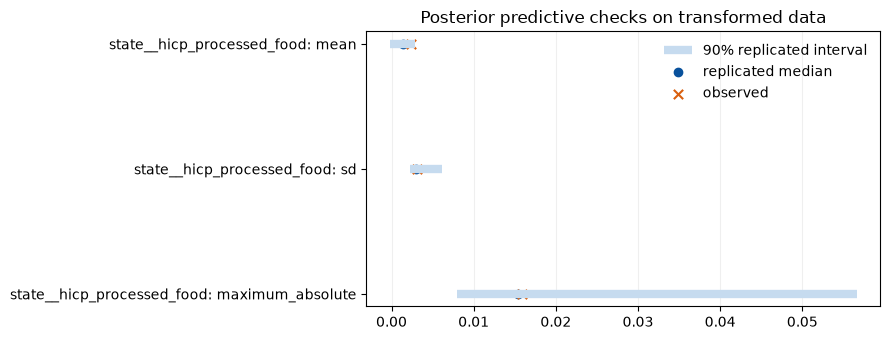

In [22]:
ppc_summary, ppc_draws = posterior_predictive_statistics(
    result,
    n_draws=min(300, result["n_draws"]),
    seed=321,
)
display(style_numeric_table(ppc_summary, caption="Posterior predictive checks"))
plot_posterior_predictive_check(ppc_summary)
plt.show()

## 16. Save / registry promotion

In [ ]:
if SAVE_RESULTS:
    if save_energy_bvar_result is None:
        raise RuntimeError("energy_bvar_io.save_energy_bvar_result is unavailable.")
    saved = save_energy_bvar_result(result, PROJECT_ROOT / "results")
    print("Saved to:", saved["directory"])
else:
    print("SAVE_RESULTS=False — estimation is not promoted to the common registry.")

SAVE_RESULTS=False — estimation is not promoted to the common registry.


: 

## Production contract

```text
processed_food_monthly.csv
    │
    ├─ hicp_processed_food          → Δlog, endogenous AR(4)
    ├─ food_commodity_price         → Δlog, L2 exogenous term
    ├─ compensation_per_employee    → Δlog, L0/L1/L2 exogenous terms
    └─ vat_standard_ea              → Δ(rate/100), L0 exogenous term

+ 11 monthly dummies

        ↓
shared Energy Bayesian engine
        ↓
ARX coefficients + SV + outliers
        ↓
conditional native-driver forecast paths
        ↓
processed-food HICP level draws
processed-food YoY draws
        ↓
Food aggregation → Headline aggregation → dashboard
```

The statistical engine remains shared; the component-specific economics live in `headline_bvar_model.py`.